# Лабораторная работа №1
## Освоение базового ML-пайплайна на табличных данных

**Датасет:** Student Depression Dataset (Kaggle) — 100 000 студентов, 11 признаков  
**Задачи:** регрессия (CGPA) + классификация (Depression)

### Импорты

In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_style('whitegrid')

RANDOM_STATE = 42

### Загрузка и первичная проверки датасета

In [14]:
# Load and inspect dataset
df = pd.read_csv('student_lifestyle_100k.csv')

df = df.rename(columns={
    'Student_ID': 'StudentID',
    'Sleep_Duration': 'SleepDuration',
    'Study_Hours': 'StudyHours',
    'Social_Media_Hours': 'SocialMediaHours',
    'Physical_Activity': 'PhysicalActivity',
    'Stress_Level': 'StressLevel'
})

print('Shape:', df.shape)
print('Missing values:', df.isna().sum().sum())


print("Total duplicates:", df.duplicated().sum())
print("Duplicates by StudentID:", df['StudentID'].duplicated().sum())

print("Genders:", df['Gender'].unique())
print("Department:", df['Department'].unique())

print("Age < 15 or > 35:", ((df['Age'] < 15) | (df['Age'] > 35)).sum())
print("CGPA < 0 or > 4:", ((df['CGPA'] < 0) | (df['CGPA'] > 4)).sum())
print("Sleep_Duration < 0 or > 24:", ((df['SleepDuration'] < 0) | (df['SleepDuration'] > 24)).sum())
print("Study_Hours < 0:", (df['StudyHours'] < 0).sum())
print("Social_Media_Hours < 0:", (df['SocialMediaHours'] < 0).sum())
print("Physical_Activity < 0:", (df['PhysicalActivity'] < 0).sum())

df.head()


print("типы данных")
print(df.dtypes)

Shape: (100000, 11)
Missing values: 0
Total duplicates: 0
Duplicates by StudentID: 0
Genders: ['Female' 'Male']
Department: ['Science' 'Engineering' 'Medical' 'Arts' 'Business']
Age < 15 or > 35: 0
CGPA < 0 or > 4: 0
Sleep_Duration < 0 or > 24: 0
Study_Hours < 0: 0
Social_Media_Hours < 0: 0
Physical_Activity < 0: 0
типы данных
StudentID             int64
Age                   int64
Gender               object
Department           object
CGPA                float64
SleepDuration       float64
StudyHours          float64
SocialMediaHours    float64
PhysicalActivity      int64
StressLevel           int64
Depression             bool
dtype: object


## 1. Разведочный анализ данных (EDA)

Определение структуры данных, поиск аномалий, пропусков, выбросов, формулировка гипотезы до обучения моделей.

In [15]:
# Logical validation checks
logical_checks = pd.DataFrame({
    'condition': [
        'Age < 0',
        'CGPA outside [0, 4]',
        'SleepDuration < 0',
        'StudyHours < 0',
        'SocialMediaHours < 0',
        'PhysicalActivity < 0',
        'StressLevel outside [1, 10]',
        'StudentID duplicated'
    ],
    'count': [
        (df['Age'] < 0).sum(),
        ((df['CGPA'] < 0) | (df['CGPA'] > 4)).sum(),
        (df['SleepDuration'] < 0).sum(),
        (df['StudyHours'] < 0).sum(),
        (df['SocialMediaHours'] < 0).sum(),
        (df['PhysicalActivity'] < 0).sum(),
        ((df['StressLevel'] < 1) | (df['StressLevel'] > 10)).sum(),
        df['StudentID'].duplicated().sum()
    ]
})

logical_checks

,condition,count
0,Age < 0,0
1,"CGPA outside [0, 4]",0
2,SleepDuration < 0,0
3,StudyHours < 0,0
4,SocialMediaHours < 0,0
5,PhysicalActivity < 0,0
6,"StressLevel outside [1, 10]",0
7,StudentID duplicated,0


### 1.1 Анализ распределений и выбросов в данных в графиках


 CGPA - mean: 2.90, median: 2.90, std: 0.53


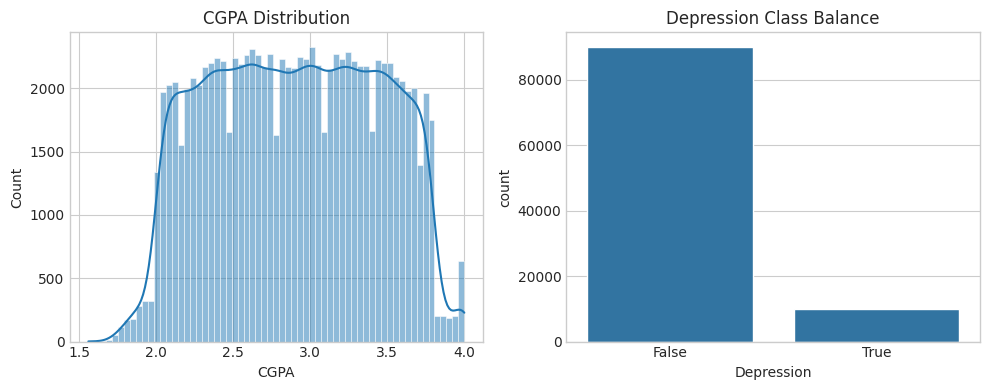

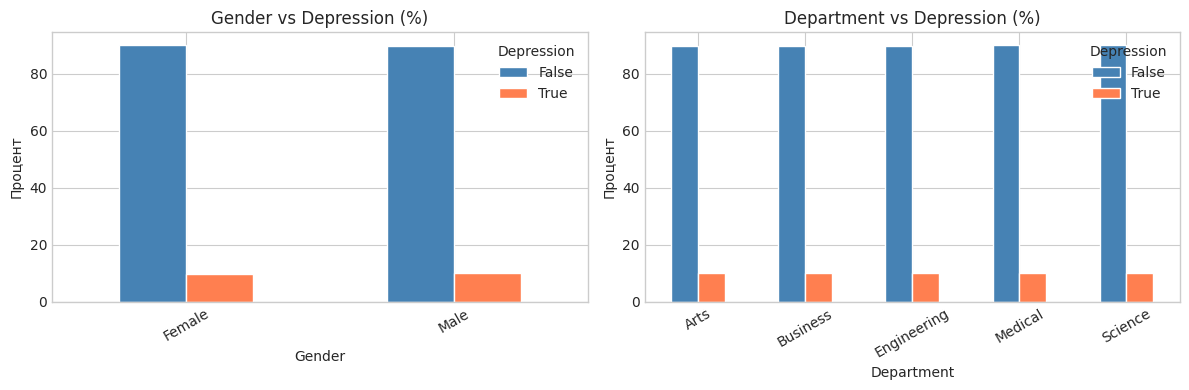

In [16]:
# Target distributions
print(f"\n CGPA - mean: {df['CGPA'].mean():.2f}, median: {df['CGPA'].median():.2f}, std: {df['CGPA'].std():.2f}")

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
sns.histplot(df['CGPA'], kde=True, ax=axes[0])
axes[0].set_title('CGPA Distribution')
sns.countplot(x='Depression', data=df, ax=axes[1])
axes[1].set_title('Depression Class Balance')
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for i, col in enumerate(['Gender', 'Department']):
    ct = pd.crosstab(df[col], df['Depression'], normalize='index') * 100
    ct.plot(kind='bar', ax=axes[i], color=['steelblue', 'coral'])
    axes[i].set_title(f'{col} vs Depression (%)')
    axes[i].set_ylabel('Процент')
    axes[i].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig('categorical_analysis.png', dpi=100)
plt.show()

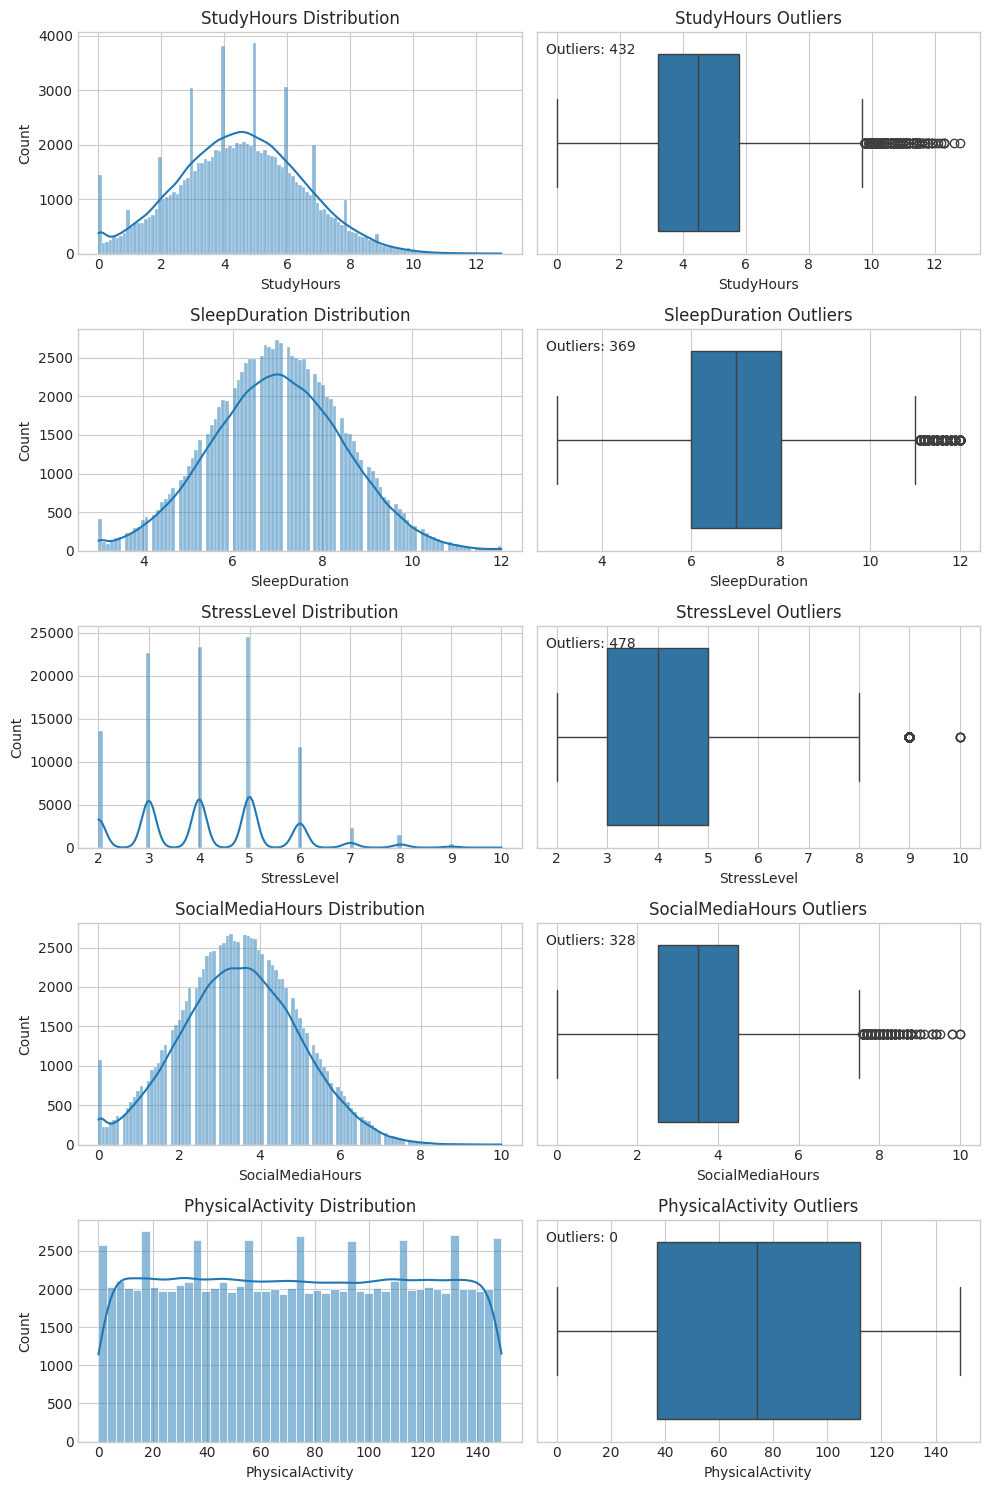

In [17]:
# Key features distribution & outlier stats
features = ['StudyHours', 'SleepDuration', 'StressLevel', 'SocialMediaHours', 'PhysicalActivity']
fig, axes = plt.subplots(len(features), 2, figsize=(10, 3*len(features)))

for i, col in enumerate(features):
    sns.histplot(df[col], kde=True, ax=axes[i, 0])
    axes[i, 0].set_title(f'{col} Distribution')
    sns.boxplot(x=df[col], ax=axes[i, 1])
    axes[i, 1].set_title(f'{col} Outliers')
    Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    IQR = Q3 - Q1
    outliers = ((df[col] < Q1 - 1.5*IQR) | (df[col] > Q3 + 1.5*IQR)).sum()
    axes[i, 1].text(0.02, 0.9, f'Outliers: {outliers}', transform=axes[i, 1].transAxes)
plt.tight_layout()
plt.show()

### 1.2 Карта корреляций

Age                    4.0015
CGPA                   0.2833
SleepDuration          2.2460
StudyHours             3.9049
SocialMediaHours       2.2107
PhysicalActivity    1880.6935
StressLevel            2.0282
Depression             0.0905
dtype: float64


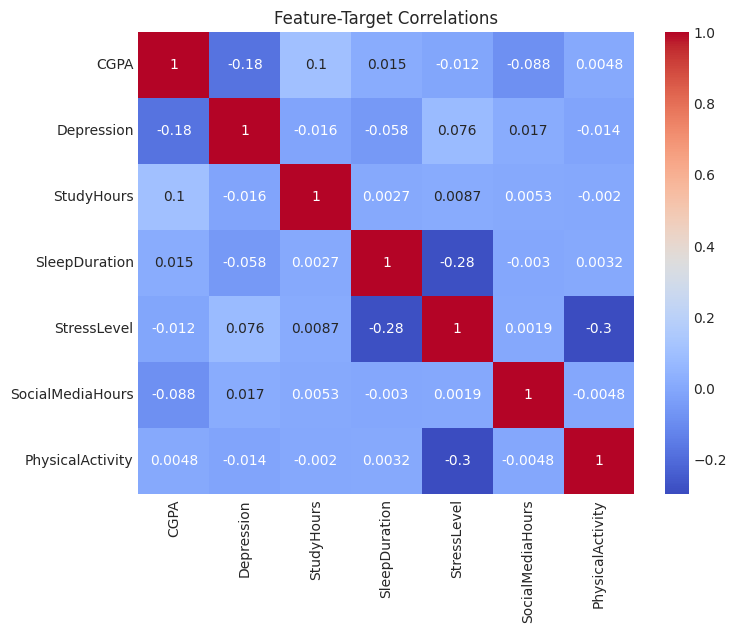

In [18]:
df_corr = df.copy()
df_corr['Depression'] = df_corr['Depression'].astype(int)

df_corr = df_corr.drop(columns=['StudentID', 'Gender', 'Department'], errors='ignore') # errors='ignore' на случай, если колонки нет



print(df_corr.var().round(4))

# Correlation with targets
plt.figure(figsize=(8, 6))
corr_cols = ['CGPA', 'Depression', 'StudyHours', 'SleepDuration', 'StressLevel', 'SocialMediaHours', 'PhysicalActivity']
sns.heatmap(df[corr_cols].corr(), annot=True, cmap='coolwarm')
plt.title('Feature-Target Correlations')
plt.show()

## 2. Предобработка данных

### 2.1 Обработка выбросов, преобразование столбцов, удаления неинформативных данных
- Удалён `Student_ID` — неинформативный идентификатор
- `Gender` → LabelEncoder (Female=0, Male=1)
- `Department` → One-Hot Encoding (5 бинарных столбцов)
- Выбросы обрезаны методом IQR clip (не удалены, чтобы сохранить строки)
- `Physical_Activity` → часы (/ 60) для сопоставимости шкал
- `StandardScaler` fit только на train во избежание data leakage

In [19]:
from sklearn.preprocessing import LabelEncoder, StandardScaler

df_processed = df.copy()

df_processed = df_processed.drop(columns=['StudentID'])

df_processed['Gender'] = LabelEncoder().fit_transform(df_processed['Gender'])

df_processed = pd.get_dummies(df_processed, columns=['Department'], drop_first=False)

df_processed['Depression'] = df_processed['Depression'].astype(int)

df_processed['PhysicalActivityHours'] = df_processed['PhysicalActivity'] / 60
df_processed = df_processed.drop(columns=['PhysicalActivity'])

def clip_iqr(series):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return series.clip(lower, upper)

for col in ['SleepDuration', 'StudyHours', 'SocialMediaHours']:
    before = ((df_processed[col] < df_processed[col].quantile(0.25) - 1.5*(df_processed[col].quantile(0.75)-df_processed[col].quantile(0.25))) |
              (df_processed[col] > df_processed[col].quantile(0.75) + 1.5*(df_processed[col].quantile(0.75)-df_processed[col].quantile(0.25)))).sum()
    df_processed[col] = clip_iqr(df_processed[col])
    print(f"{col}: обрезано выбросов = {before}")

print("\nФинальные столбцы:")
print(df_processed.columns.tolist())
print("\nРазмер после предобработки:", df_processed.shape)

SleepDuration: обрезано выбросов = 369
StudyHours: обрезано выбросов = 432
SocialMediaHours: обрезано выбросов = 328

Финальные столбцы:
['Age', 'Gender', 'CGPA', 'SleepDuration', 'StudyHours', 'SocialMediaHours', 'StressLevel', 'Depression', 'Department_Arts', 'Department_Business', 'Department_Engineering', 'Department_Medical', 'Department_Science', 'PhysicalActivityHours']

Размер после предобработки: (100000, 14)


### 2.2 Проверка данных после предобработки

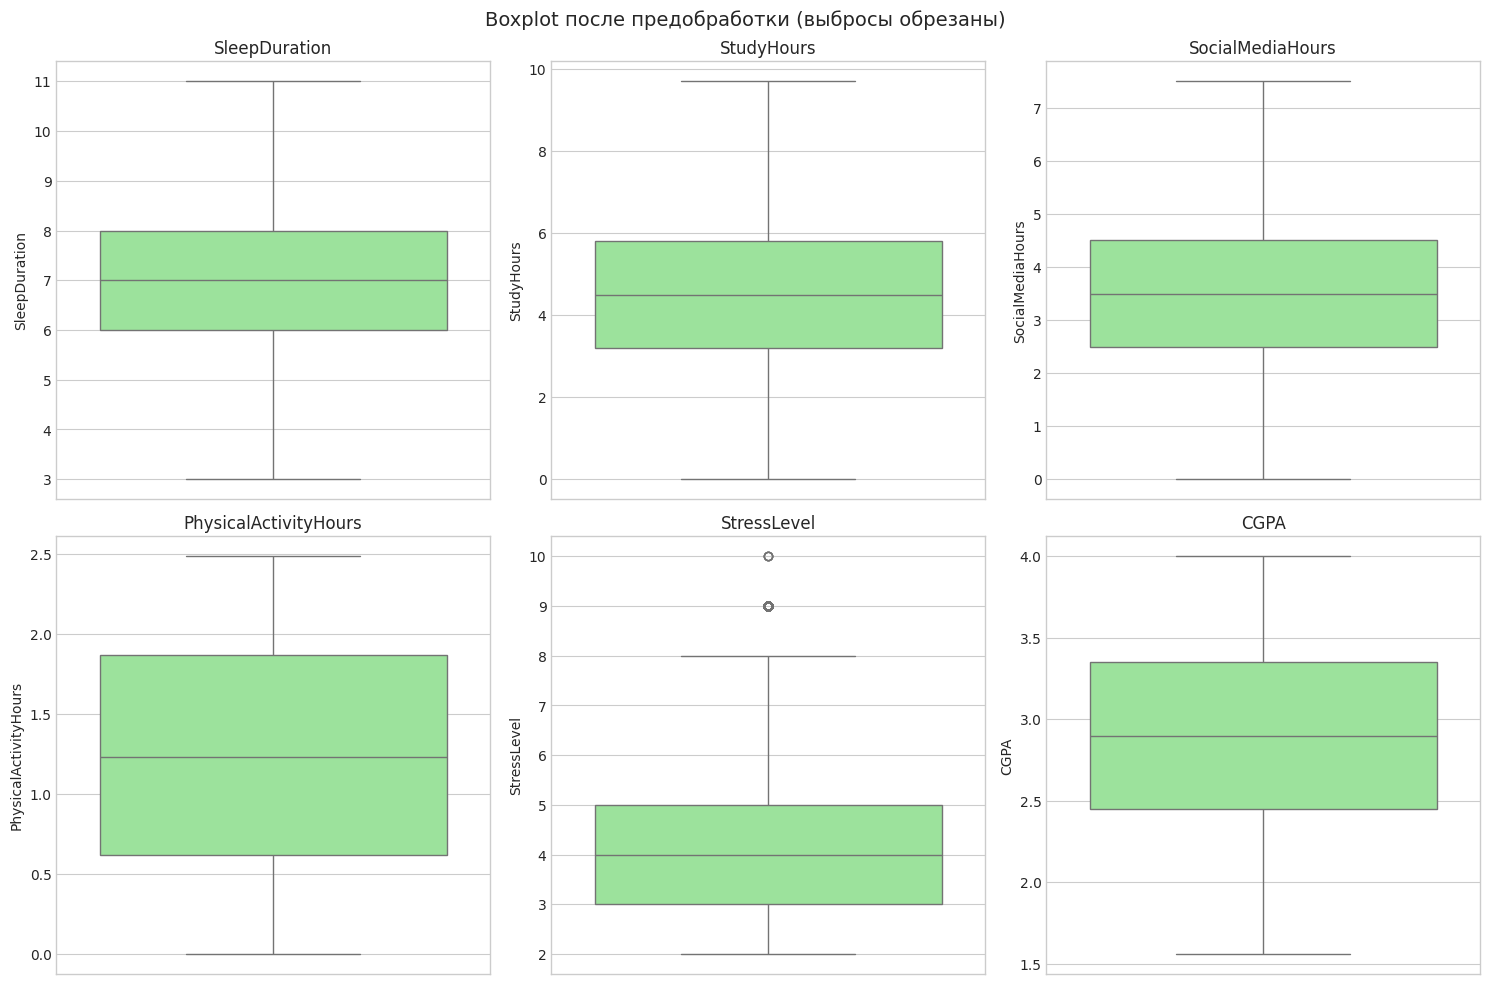

       SleepDuration  StudyHours  SocialMediaHours  PhysicalActivityHours
count     100000.000  100000.000        100000.000             100000.000
mean           6.995       4.507             3.502                  1.239
std            1.493       1.967             1.482                  0.723
min            3.000       0.000             0.000                  0.000
25%            6.000       3.200             2.500                  0.617
50%            7.000       4.500             3.500                  1.233
75%            8.000       5.800             4.500                  1.867
max           11.000       9.700             7.500                  2.483
Age                         int64
Gender                      int64
CGPA                      float64
SleepDuration             float64
StudyHours                float64
SocialMediaHours          float64
StressLevel                 int64
Depression                  int64
Department_Arts              bool
Department_Business         

In [20]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle('Boxplot после предобработки (выбросы обрезаны)', fontsize=14)

check_cols = ['SleepDuration', 'StudyHours', 'SocialMediaHours',
              'PhysicalActivityHours', 'StressLevel', 'CGPA']

for i, col in enumerate(check_cols):
    ax = axes[i // 3][i % 3]
    sns.boxplot(y=df_processed[col], ax=ax, color='lightgreen')
    ax.set_title(col)

plt.tight_layout()
plt.savefig('boxplots_after.png', dpi=100)
plt.show()

print(df_processed[['SleepDuration', 'StudyHours', 'SocialMediaHours',
                     'PhysicalActivityHours']].describe().round(3))

print(df_processed.dtypes)

print(df_processed.isnull().sum().sum(), "пропусков")

In [21]:
dept_cols = ['Department_Arts', 'Department_Business', 'Department_Engineering',
             'Department_Medical', 'Department_Science']
df_processed[dept_cols] = df_processed[dept_cols].astype(int)
print(df_processed.dtypes)

Age                         int64
Gender                      int64
CGPA                      float64
SleepDuration             float64
StudyHours                float64
SocialMediaHours          float64
StressLevel                 int64
Depression                  int64
Department_Arts             int64
Department_Business         int64
Department_Engineering      int64
Department_Medical          int64
Department_Science          int64
PhysicalActivityHours     float64
dtype: object


## 3. Feature engineering

### 3.1 Создание новых признаков

1) Study_to_Social_ratio = Study_Hours / (Social_Media_Hours + 0.1) — продуктивность
2) Total_load = Study_Hours × Stress_Level — суммарная нагрузка
3) Wellness_score = Sleep_Duration + Physical_Activity_hours — здоровый образ жизни

In [22]:
df_processed['StudySleepRatio'] = df_processed['StudyHours'] / (df_processed['SleepDuration'] + 1e-3)

df_processed['TotalLoad'] = df_processed['StudyHours'] * df_processed['StressLevel']

df_processed['WellnessScore'] = df_processed['SleepDuration'] + df_processed['PhysicalActivityHours']

df_processed.head()

,Age,Gender,CGPA,SleepDuration,StudyHours,SocialMediaHours,StressLevel,Depression,Department_Arts,Department_Business,Department_Engineering,Department_Medical,Department_Science,PhysicalActivityHours,StudySleepRatio,TotalLoad,WellnessScore
0,22,0,3.50,7.3,3.3,3.4,5,0,0,0,0,0,1,1.900000,0.451993,16.5,9.200000
1,20,1,2.72,5.5,7.2,6.0,2,0,0,0,1,0,0,2.366667,1.308853,14.4,7.866667
2,20,1,3.01,5.4,2.3,1.8,3,0,0,0,0,1,0,2.283333,0.425847,6.9,7.683333
3,21,1,3.63,8.1,2.0,4.6,3,0,0,0,1,0,0,2.166667,0.246883,6.0,10.266667
4,19,1,3.14,6.8,2.6,4.3,6,0,1,0,0,0,0,0.066667,0.382297,15.6,6.866667


### 3.2 Проверка корреляций

In [23]:
feature_cols = [c for c in df_processed.columns if c not in ['CGPA', 'Depression']]

corr_with_cgpa = df_processed[feature_cols + ['CGPA']].corr()['CGPA'].drop('CGPA').sort_values(key=abs, ascending=False)
corr_with_depression = df_processed[feature_cols + ['Depression']].corr()['Depression'].drop('Depression').sort_values(key=abs, ascending=False)

print("\n=== КОРРЕЛЯЦИЯ С CGPA ===")
print(corr_with_cgpa.round(4))

print("\n=== КОРРЕЛЯЦИЯ С DEPRESSION ===")
print(corr_with_depression.round(4))


=== КОРРЕЛЯЦИЯ С CGPA ===
StudyHours                0.0993
SocialMediaHours         -0.0881
StudySleepRatio           0.0731
TotalLoad                 0.0672
WellnessScore             0.0158
SleepDuration             0.0153
StressLevel              -0.0123
Gender                   -0.0052
PhysicalActivityHours     0.0048
Department_Arts           0.0041
Age                       0.0032
Department_Medical       -0.0021
Department_Engineering   -0.0011
Department_Business      -0.0006
Department_Science       -0.0003
Name: CGPA, dtype: float64

=== КОРРЕЛЯЦИЯ С DEPRESSION ===
StressLevel               0.0759
WellnessScore            -0.0579
SleepDuration            -0.0577
TotalLoad                 0.0329
StudySleepRatio           0.0230
SocialMediaHours          0.0170
StudyHours               -0.0160
PhysicalActivityHours    -0.0139
Age                      -0.0077
Gender                    0.0045
Department_Business       0.0021
Department_Science       -0.0019
Department_Medical    

## 4. Разделение данных на выборки

### 4.1 Определение данных для обчения каждой из моделей

In [24]:
# Define regression and classification features
regression_features = [
    'SleepDuration',
    'StudyHours',
    'Gender',
    'StudySleepRatio',
    'SocialMediaHours',
    'TotalLoad',
    'PhysicalActivityHours',
    "StressLevel"

]

classification_features = [
    'WellnessScore',
    'TotalLoad',
    'CGPA',
    'SleepDuration',
    'StudyHours',
    'SocialMediaHours',
    'StressLevel',
    'StudySleepRatio'
]

print('Regression features:', regression_features)
print('Classification features:', classification_features)

Regression features: ['SleepDuration', 'StudyHours', 'Gender', 'StudySleepRatio', 'SocialMediaHours', 'TotalLoad', 'PhysicalActivityHours', 'StressLevel']
Classification features: ['WellnessScore', 'TotalLoad', 'CGPA', 'SleepDuration', 'StudyHours', 'SocialMediaHours', 'StressLevel', 'StudySleepRatio']


### 4.2 Разбиение 70% / 15% / 15% (train / val / test)

In [25]:
from sklearn.model_selection import train_test_split


# targets and features
X_reg = df_processed[regression_features]
y_reg = df_processed['CGPA']

X_clf = df_processed[classification_features]
y_clf = df_processed['Depression']

# regression split
X_train_reg, X_temp_reg, y_train_reg, y_temp_reg = train_test_split(
    X_reg, y_reg, test_size=0.15, random_state=RANDOM_STATE
)

X_val_reg, X_test_reg, y_val_reg, y_test_reg = train_test_split(
    X_temp_reg, y_temp_reg, test_size=0.1765, random_state=RANDOM_STATE
)

# classification split
X_train_clf, X_temp_clf, y_train_clf, y_temp_clf = train_test_split(
    X_clf, y_clf, test_size=0.15, random_state=RANDOM_STATE, stratify=y_clf
)

X_val_clf, X_test_clf, y_val_clf, y_test_clf = train_test_split(
    X_temp_clf, y_temp_clf, test_size=0.1765, random_state=RANDOM_STATE, stratify=y_temp_clf
)

print('Regression split sizes:', X_train_reg.shape[0], X_val_reg.shape[0], X_test_reg.shape[0])
print('Classification split sizes:', X_train_clf.shape[0], X_val_clf.shape[0], X_test_clf.shape[0])
print('Depression share in train:', y_train_clf.mean())
print('Depression share in val:', y_val_clf.mean())
print('Depression share in test:', y_test_clf.mean())

Regression split sizes: 85000 12352 2648
Classification split sizes: 85000 12352 2648
Depression share in train: 0.10062352941176471
Depression share in val: 0.10063147668393782
Depression share in test: 0.10045317220543806


## 5. Обучение Линейной регрессии для предсказания CGPA

### 5.1 Обучение и проверка основных метрик

In [26]:
from sklearn.linear_model import LinearRegression
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Train Linear Regression
num_features_reg = regression_features

preprocessor_reg = ColumnTransformer(
    transformers=[
        ('num', Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler())
        ]), num_features_reg)
    ],
    remainder='drop'
)

linreg_model = Pipeline([
    ('preprocessor', preprocessor_reg),
    ('model', LinearRegression())
])

linreg_model.fit(X_train_reg, y_train_reg)

y_pred_train_reg = linreg_model.predict(X_train_reg)
y_pred_val_reg = linreg_model.predict(X_val_reg)
y_pred_test_reg = linreg_model.predict(X_test_reg)

print('Linear Regression Results')
print(f'Train R²:      {r2_score(y_train_reg, y_pred_train_reg):.4f},    RMSE: {np.sqrt(mean_squared_error(y_train_reg, y_pred_train_reg)):.4f}')
print(f'Validation R²: {r2_score(y_val_reg, y_pred_val_reg):.4f},    RMSE: {np.sqrt(mean_squared_error(y_val_reg, y_pred_val_reg)):.4f}')
print(f'Test R²:       {r2_score(y_test_reg, y_pred_test_reg):.4f},    RMSE: {np.sqrt(mean_squared_error(y_test_reg, y_pred_test_reg)):.4f}')

Linear Regression Results
Train R²:      0.0186,    RMSE: 0.5269
Validation R²: 0.0171,    RMSE: 0.5306
Test R²:       0.0142,    RMSE: 0.5267


### 5.2 Визуализация результатов обучения

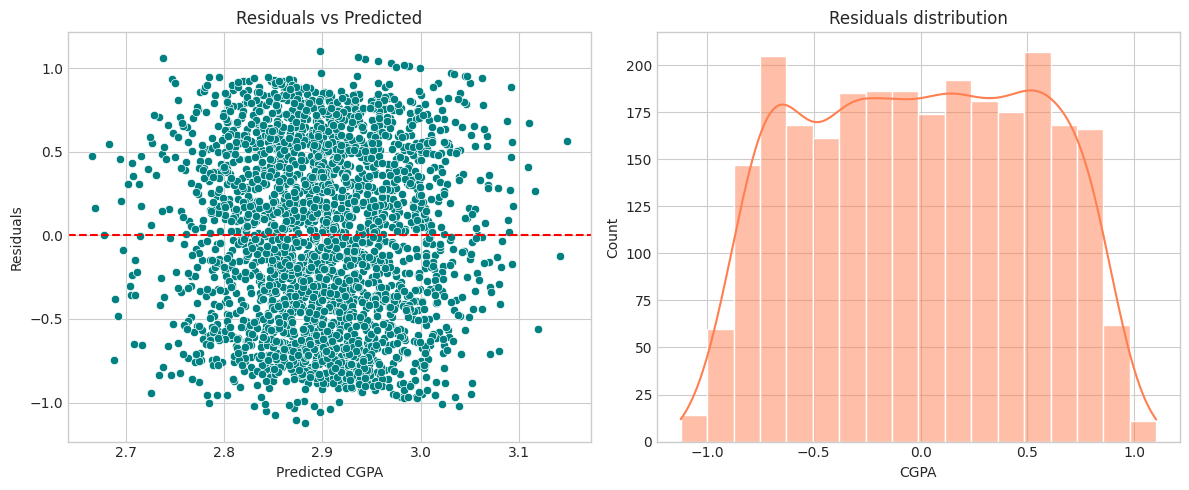

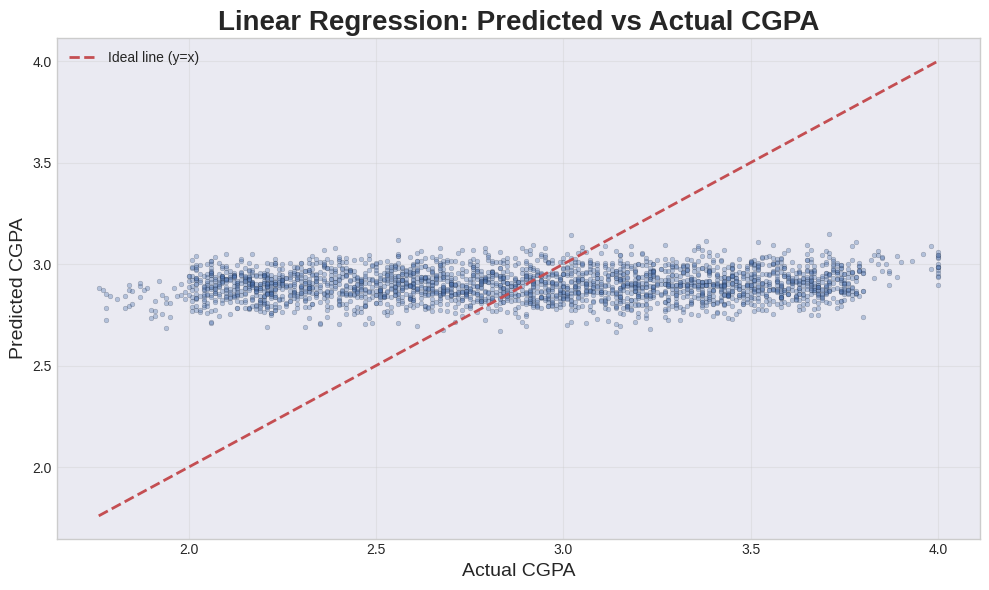

Residuals Statistics:
  Mean: -0.0036
  Std:  0.5266
  Min:  -1.1224
  Max:  1.1025


In [27]:
# residual analysis visualization
residuals = y_test_reg - y_pred_test_reg

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.scatterplot(x=y_pred_test_reg, y=residuals, ax=axes[0], color='teal')
axes[0].axhline(0, color='red', linestyle='--')
axes[0].set_title('Residuals vs Predicted')
axes[0].set_xlabel('Predicted CGPA')
axes[0].set_ylabel('Residuals')

sns.histplot(residuals, kde=True, ax=axes[1], color='coral')
axes[1].set_title('Residuals distribution')

plt.tight_layout()
plt.show()


# predicted vs actual CGPA

import numpy as np
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-whitegrid')

fig, ax = plt.subplots(figsize=(10, 6))

ax.set_facecolor('#EAEAF2')

ax.scatter(
    y_test_reg,
    y_pred_test_reg,
    alpha=0.35,
    s=12,
    c='#4C72B0',
    edgecolors='black',
    linewidths=0.25
)

print()

# ideal line y = x
line_min = min(np.min(y_test_reg), np.min(y_pred_test_reg))
line_max = max(np.max(y_test_reg), np.max(y_pred_test_reg))
ax.plot(
    [line_min, line_max],
    [line_min, line_max],
    linestyle='--',
    color='#C44E52',
    linewidth=2,
    label='Ideal line (y=x)'
)

ax.set_xlabel('Actual CGPA', fontsize=14)
ax.set_ylabel('Predicted CGPA', fontsize=14)
ax.set_title('Linear Regression: Predicted vs Actual CGPA', fontsize=20, fontweight='bold')

ax.legend(loc='upper left', frameon=False)
ax.grid(True, alpha=0.35)

plt.tight_layout()
plt.show()

# additional statistics
residuals = y_test_reg - y_pred_test_reg

print("Residuals Statistics:")
print(f"  Mean: {np.mean(residuals):.4f}")
print(f"  Std:  {np.std(residuals):.4f}")
print(f"  Min:  {np.min(residuals):.4f}")
print(f"  Max:  {np.max(residuals):.4f}")

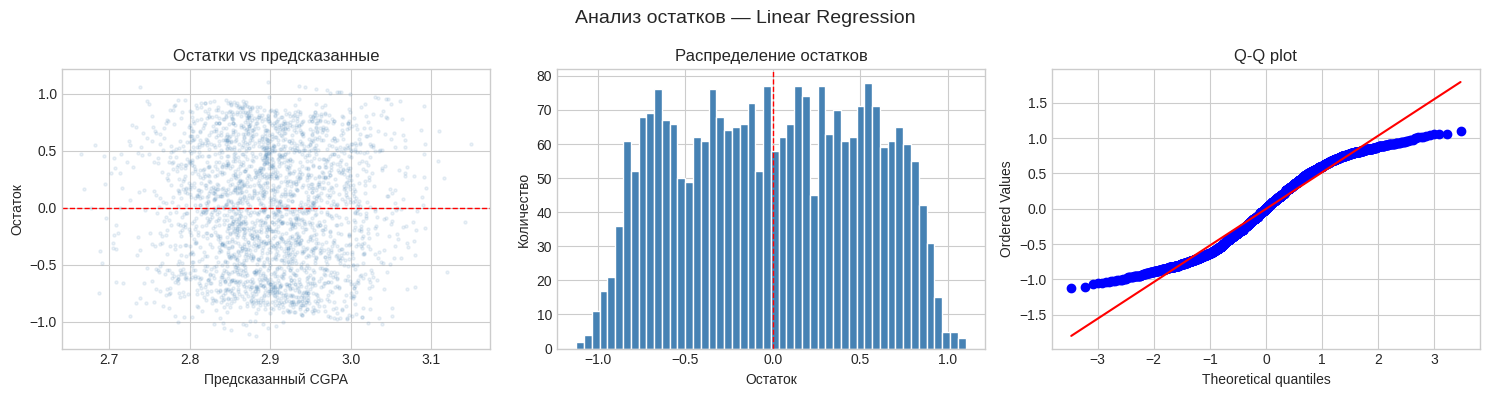

Среднее остатков: -0.0036 (должно быть ~0)
Std остатков: 0.5267


In [28]:
residuals = y_test_reg - y_pred_test_reg

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Анализ остатков — Linear Regression', fontsize=14)

# 1. Остатки vs предсказанные значения
axes[0].scatter(y_pred_test_reg, residuals, alpha=0.1, s=5, color='steelblue')
axes[0].axhline(y=0, color='red', linestyle='--', linewidth=1)
axes[0].set_xlabel('Предсказанный CGPA')
axes[0].set_ylabel('Остаток')
axes[0].set_title('Остатки vs предсказанные')

# 2. Распределение остатков
axes[1].hist(residuals, bins=50, color='steelblue', edgecolor='white')
axes[1].axvline(x=0, color='red', linestyle='--', linewidth=1)
axes[1].set_xlabel('Остаток')
axes[1].set_ylabel('Количество')
axes[1].set_title('Распределение остатков')

# 3. Q-Q plot
from scipy import stats
stats.probplot(residuals, dist="norm", plot=axes[2])
axes[2].set_title('Q-Q plot')

plt.tight_layout()
plt.savefig('residuals.png', dpi=100)
plt.show()

print(f"Среднее остатков: {residuals.mean():.4f} (должно быть ~0)")
print(f"Std остатков: {residuals.std():.4f}")

## 6 Обучение логистической регрессии для предсказания Depression

In [29]:
from sklearn.linear_model import SGDClassifier
from sklearn.base import clone
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, classification_report, roc_curve, precision_recall_curve, auc
)
import pandas as pd

# === SGDClassifier hyperparameter grid search ===

preprocessor_clf = ColumnTransformer(
    transformers=[
        ('num', Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler())
        ]), classification_features)
    ],
    remainder='drop'
)

learning_rates = [0.001, 0.01, 0.05, 0.1]
epochs_list = [50, 100, 200, 500]

experiment_results = []
best_model = None
best_score = -1
best_params = None

for lr in learning_rates:
    for epochs in epochs_list:
        clf_model = Pipeline([
            ('preprocessor', preprocessor_clf),
            ('classifier', SGDClassifier(
                loss='log_loss',
                learning_rate='constant',
                eta0=lr,
                max_iter=epochs,
                tol=1e-3,
                early_stopping=True,
                validation_fraction=0.1,
                class_weight='balanced',
                random_state=RANDOM_STATE
            ))
        ])

        clf_model.fit(X_train_clf, y_train_clf)

        train_pred = clf_model.predict(X_train_clf)
        val_pred = clf_model.predict(X_val_clf)
        val_proba = clf_model.predict_proba(X_val_clf)[:, 1]

        val_f1 = f1_score(y_val_clf, val_pred)
        val_auc = roc_auc_score(y_val_clf, val_proba)

        experiment_results.append({
            'learning_rate': lr,
            'epochs': epochs,
            'train_accuracy': accuracy_score(y_train_clf, train_pred),
            'val_accuracy': accuracy_score(y_val_clf, val_pred),
            'train_f1': f1_score(y_train_clf, train_pred),
            'val_f1': val_f1,
            'val_roc_auc': val_auc
        })

        if val_f1 > best_score:
            best_score = val_f1
            best_model = clf_model
            best_params = {'learning_rate': lr, 'epochs': epochs}
            best_auc = val_auc


print("=== learning rate и epochs ===")
print(f"{'LR':>10} {'Epochs':>8} {'Train F1':>12} {'Val F1':>12} {'Val AUC':>12}")
print("-" * 58)

# from best to worst
sorted_results = sorted(experiment_results, key=lambda x: x['val_f1'], reverse=True)

for res in sorted_results:
    print(f"{res['learning_rate']:>10.4f} {res['epochs']:>8} "
          f"{res['train_f1']:>12.4f} {res['val_f1']:>12.4f} {res['val_roc_auc']:>12.4f}")

print("-" * 58)
print(f"\nbest configuration:")
print(f"   learning_rate: {best_params['learning_rate']}")
print(f"   epochs:        {best_params['epochs']}")
print(f"   Val F1:        {best_score:.4f}")
print(f"   Val AUC:       {best_auc:.4f}")

=== learning rate и epochs ===
        LR   Epochs     Train F1       Val F1      Val AUC
----------------------------------------------------------
    0.0100       50       0.2713       0.2661       0.6712
    0.0100      100       0.2713       0.2661       0.6712
    0.0100      200       0.2713       0.2661       0.6712
    0.0100      500       0.2713       0.2661       0.6712
    0.0010       50       0.2686       0.2595       0.6740
    0.0010      100       0.2686       0.2595       0.6740
    0.0010      200       0.2686       0.2595       0.6740
    0.0010      500       0.2686       0.2595       0.6740
    0.1000       50       0.1858       0.1950       0.5598
    0.1000      100       0.1858       0.1950       0.5598
    0.1000      200       0.1858       0.1950       0.5598
    0.1000      500       0.1858       0.1950       0.5598
    0.0500       50       0.1839       0.1929       0.5577
    0.0500      100       0.1839       0.1929       0.5577
    0.0500      200      

## 7. Оценка модели и доказательство отсутствия переобучения

=== ФИНАЛЬНЫЕ МЕТРИКИ (lr=0.01, epochs=50) ===

Train:
  Accuracy:  0.6830
  F1:        0.2713
  Precision: 0.1765
  Recall:    0.5863

Val:
  Accuracy:  0.6790
  F1:        0.2661
  Precision: 0.1728
  Recall:    0.5784

Test:
  Accuracy:  0.6794
  F1:        0.2774
  Precision: 0.1793
  Recall:    0.6128

=== CLASSIFICATION REPORT (Test) ===
               precision    recall  f1-score   support

No Depression       0.94      0.69      0.79      2382
   Depression       0.18      0.61      0.28       266

     accuracy                           0.68      2648
    macro avg       0.56      0.65      0.54      2648
 weighted avg       0.86      0.68      0.74      2648



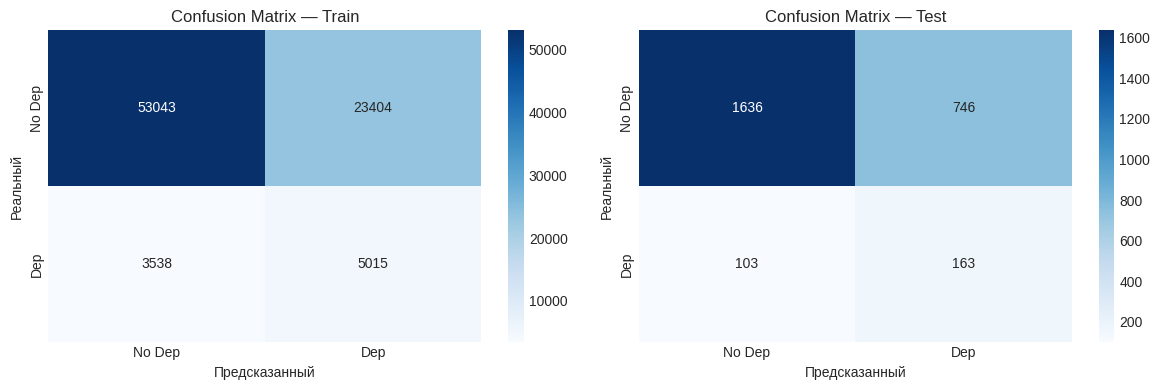

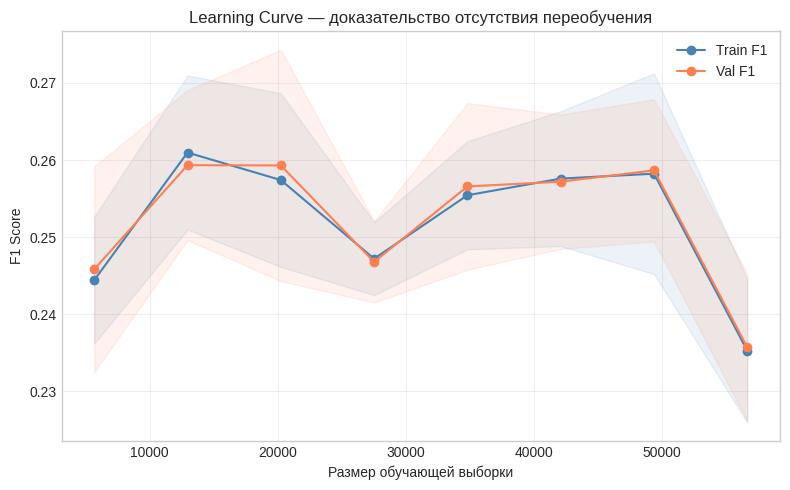

In [30]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix
)
from sklearn.model_selection import learning_curve
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# === ФИНАЛЬНАЯ МОДЕЛЬ ===
final_model = best_model  # обученный пайплайн preprocessor + SGD

# Предсказания
y_train_pred = final_model.predict(X_train_clf)
y_val_pred   = final_model.predict(X_val_clf)
y_test_pred  = final_model.predict(X_test_clf)

print(f"=== ФИНАЛЬНЫЕ МЕТРИКИ (lr={best_params['learning_rate']}, "
      f"epochs={best_params['epochs']}) ===")

for name, y_true, y_pred in [
    ('Train', y_train_clf, y_train_pred),
    ('Val',   y_val_clf,   y_val_pred),
    ('Test',  y_test_clf,  y_test_pred)
]:
    print(f"\n{name}:")
    print(f"  Accuracy:  {accuracy_score(y_true, y_pred):.4f}")
    print(f"  F1:        {f1_score(y_true, y_pred):.4f}")
    print(f"  Precision: {precision_score(y_true, y_pred):.4f}")
    print(f"  Recall:    {recall_score(y_true, y_pred):.4f}")

print("\n=== CLASSIFICATION REPORT (Test) ===")
print(classification_report(
    y_test_clf,
    y_test_pred,
    target_names=['No Depression', 'Depression']
))

# === Confusion matrices Train/Test ===

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, (name, y_true, y_pred) in zip(axes, [
    ('Train', y_train_clf, y_train_pred),
    ('Test',  y_test_clf,  y_test_pred)
]):
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        ax=ax,
        xticklabels=['No Dep', 'Dep'],
        yticklabels=['No Dep', 'Dep']
    )
    ax.set_title(f'Confusion Matrix — {name}')
    ax.set_ylabel('Реальный')
    ax.set_xlabel('Предсказанный')

plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=100)
plt.show()

# === Learning curve — доказательство отсутствия переобучения ===

base_clf = Pipeline([
    ('preprocessor', preprocessor_clf),
    ('classifier', SGDClassifier(
        loss='log_loss',
        learning_rate='constant',
        eta0=best_params['learning_rate'],
        max_iter=best_params['epochs'],
        tol=1e-3,
        early_stopping=True,
        validation_fraction=0.1,
        class_weight='balanced',
        random_state=RANDOM_STATE
    ))
])

train_sizes, train_scores, val_scores = learning_curve(
    estimator=base_clf,
    X=X_train_clf,
    y=y_train_clf,
    train_sizes=np.linspace(0.1, 1.0, 8),
    scoring='f1',
    cv=3,
    n_jobs=-1,
    shuffle=True,
    random_state=RANDOM_STATE
)

train_mean = train_scores.mean(axis=1)
train_std  = train_scores.std(axis=1)
val_mean   = val_scores.mean(axis=1)
val_std    = val_scores.std(axis=1)

plt.figure(figsize=(8, 5))
plt.plot(train_sizes, train_mean, 'o-', label='Train F1', color='steelblue')
plt.plot(train_sizes, val_mean,   'o-', label='Val F1',   color='coral')

plt.fill_between(
    train_sizes, train_mean - train_std, train_mean + train_std,
    alpha=0.1, color='steelblue'
)
plt.fill_between(
    train_sizes, val_mean - val_std, val_mean + val_std,
    alpha=0.1, color='coral'
)

plt.xlabel('Размер обучающей выборки')
plt.ylabel('F1 Score')
plt.title('Learning Curve — доказательство отсутствия переобучения')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('learning_curve.png', dpi=100)
plt.show()

## 8. Метрики качества: ROC-кривая и коэффициенты моделей

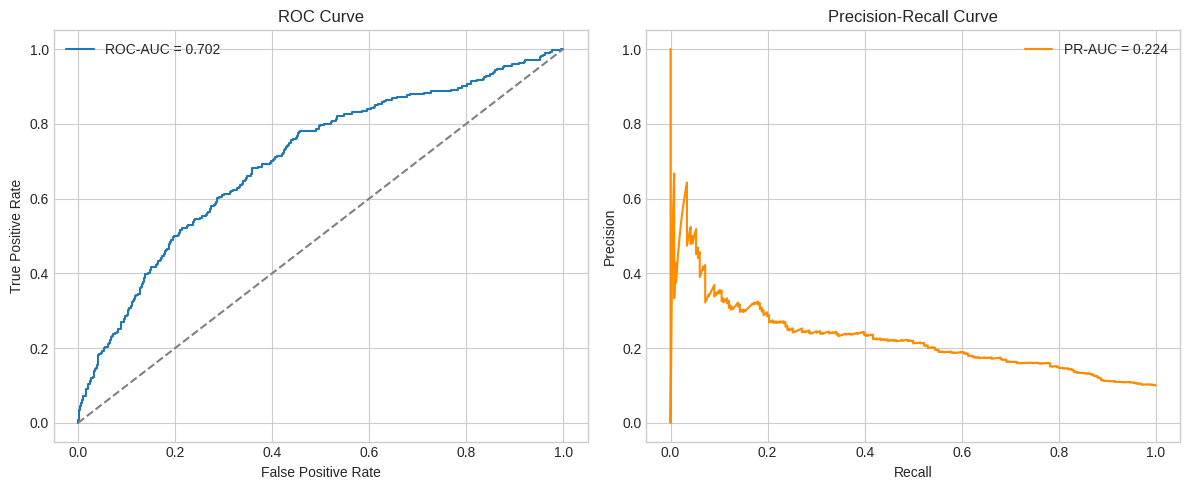

Overfitting check:
Train F1 = 0.2713
Val F1   = 0.2661
Test F1  = 0.2774
Conclusion: no strong signs of overfitting


In [31]:
from sklearn.metrics import roc_curve, auc

# === ROC и Precision-Recall для ЛУЧШЕЙ модели ===
# В ноутбуке уже есть:
# y_test_clf, y_test_pred, а вероятности лучше посчитать так:
y_test_proba = final_model.predict_proba(X_test_clf)[:, 1]

fpr, tpr, _ = roc_curve(y_test_clf, y_test_proba)
precision, recall, _ = precision_recall_curve(y_test_clf, y_test_proba)
pr_auc = auc(recall, precision)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].plot(fpr, tpr,
             label=f'ROC-AUC = {roc_auc_score(y_test_clf, y_test_proba):.3f}')
axes[0].plot([0, 1], [0, 1], linestyle='--', color='gray')
axes[0].set_title('ROC Curve')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].legend()

axes[1].plot(recall, precision,
             label=f'PR-AUC = {pr_auc:.3f}', color='darkorange')
axes[1].set_title('Precision-Recall Curve')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].legend()

plt.tight_layout()
plt.show()

# === Проверка переобучения (имена из блока с final_model) ===
train_f1 = f1_score(y_train_clf, y_train_pred)
val_f1   = f1_score(y_val_clf,   y_val_pred)
test_f1  = f1_score(y_test_clf,  y_test_pred)

print('Overfitting check:')
print(f'Train F1 = {train_f1:.4f}')
print(f'Val F1   = {val_f1:.4f}')
print(f'Test F1  = {test_f1:.4f}')

if abs(train_f1 - val_f1) < 0.05 and abs(val_f1 - test_f1) < 0.05:
    print('Conclusion: no strong signs of overfitting')
else:
    print('Conclusion: possible overfitting')

## 9. Матрица корреляции после предобработки

Проверка на отсутствие искажения данных после предобработки

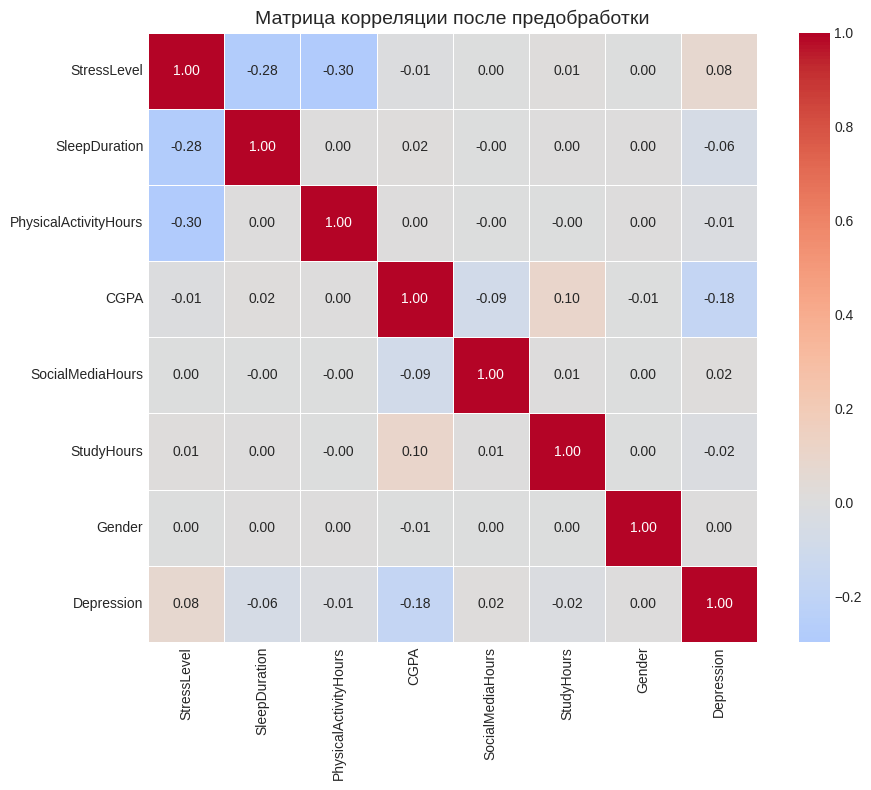

In [32]:
cols = ['StressLevel', 'SleepDuration', 'PhysicalActivityHours',
        'CGPA', 'SocialMediaHours', 'StudyHours',
        'Gender', 'Depression']

df_final_corr = df_processed[cols].copy()

plt.figure(figsize=(10, 8))
corr_final = df_final_corr.corr()
sns.heatmap(corr_final,
            annot=True,
            fmt='.2f',
            cmap='coolwarm',
            center=0,
            square=True,
            linewidths=0.5)
plt.title('Матрица корреляции после предобработки', fontsize=14)
plt.tight_layout()
plt.savefig('correlation_matrix_final.png', dpi=100)
plt.show()


In [33]:
print("=== ДИСПЕРСИЯ ПОСЛЕ ПРЕДОБРАБОТКИ ===")
cols_check = ['SleepDuration', 'StudyHours', 'SocialMediaHours',
              'PhysicalActivityHours', 'StressLevel', 'CGPA']
print(df_processed[cols_check].var().round(4))

print("\n=== СРАВНЕНИЕ ДО / ПОСЛЕ ===")
compare = pd.DataFrame({
    'До': {
        'SleepDuration': 2.2460,
        'StudyHours': 3.9049,
        'SocialMediaHours': 2.2107,
        'PhysicalActivity': 1880.6935,
        'StressLevel': 2.0282,
        'CGPA': 0.2833
    },
    'После': df_processed[cols_check].var().round(4)
})
print(compare)

=== ДИСПЕРСИЯ ПОСЛЕ ПРЕДОБРАБОТКИ ===
SleepDuration            2.2303
StudyHours               3.8701
SocialMediaHours         2.1956
PhysicalActivityHours    0.5224
StressLevel              2.0282
CGPA                     0.2833
dtype: float64

=== СРАВНЕНИЕ ДО / ПОСЛЕ ===
                              До   После
CGPA                      0.2833  0.2833
PhysicalActivity       1880.6935     NaN
PhysicalActivityHours        NaN  0.5224
SleepDuration             2.2460  2.2303
SocialMediaHours          2.2107  2.1956
StressLevel               2.0282  2.0282
StudyHours                3.9049  3.8701


## 10. Предсказание собственной оценки и депрессии

In [34]:
my_data = pd.DataFrame([{
    'Age': 19,
    'Gender': 0,              # 0 = Male, 1 = Female
    'CGPA': 0.0,
    'SleepDuration': 8.0,
    'StudyHours': 5.5,
    'SocialMediaHours': 2.0,
    'PhysicalActivityHours': 10.0,
    'StressLevel': 3,
    'DepartmentArts': 0,
    'DepartmentBusiness': 0,
    'DepartmentEngineering': 1,
    'DepartmentMedical': 0,
    'DepartmentScience': 0,
}])

# engineered features
my_data['StudySleepRatio'] = my_data['StudyHours'] / (my_data['SleepDuration'] + 1e-3)
my_data['TotalLoad'] = my_data['StudyHours'] + my_data['StressLevel']
my_data['WellnessScore'] = my_data['SleepDuration'] + my_data['PhysicalActivityHours']

print('My input data:')
display(my_data)


clf_for_me = final_model if 'final_model' in globals() else best_model

#  CGPA pred
my_cgpa_pred = linreg_model.predict(my_data[regression_features])[0]

# Update CGPA in data
my_data['CGPA'] = my_cgpa_pred

# depression pred
my_depression_pred = clf_for_me.predict(my_data[classification_features])[0]
my_depression_proba = clf_for_me.predict_proba(my_data[classification_features])[0, 1]

print(f'Predicted CGPA: {my_cgpa_pred:.3f}')
print(f'Predicted probability of depression: {my_depression_proba:.3f}')
print(f'Predicted depression class: {"Yes" if my_depression_pred == 1 else "No"}')

My input data:


,Age,Gender,CGPA,SleepDuration,StudyHours,SocialMediaHours,PhysicalActivityHours,StressLevel,DepartmentArts,DepartmentBusiness,DepartmentEngineering,DepartmentMedical,DepartmentScience,StudySleepRatio,TotalLoad,WellnessScore
0,19,0,0.0,8.0,5.5,2.0,10.0,3,0,0,1,0,0,0.687414,8.5,18.0


Predicted CGPA: 3.011
Predicted probability of depression: 0.176
Predicted depression class: No


## 11. Итоговый отчёт

### 1. Описание и первичный анализ данных

Датасет `student_lifestyle_100k.csv` содержит 100 000 строк и 11 признаков; после загрузки названия колонок были укорочены (`Student_ID` → `StudentID`, `Sleep_Duration` → `SleepDuration`, `Study_Hours` → `StudyHours` и т.д.).  
В данных нет пропусков и дубликатов (в том числе по `StudentID`), типы: числовые (`StudentID`, `Age`, `CGPA`, `SleepDuration`, `StudyHours`, `SocialMediaHours`, `PhysicalActivity`, `StressLevel`), категориальные (`Gender`, `Department`), целевая булева `Depression`.

Через простые логические проверки подтверждено, что нет наблюдений с невозможными значениями (отрицательный возраст, CGPA вне [0, 4], отрицательные часы, стресс вне [1, 10]).

***

### 2. Разведочный анализ данных (EDA)

Для числовых признаков построены описательные статистики и визуализации (гистограммы, boxplot’ы), что позволило оценить форму распределений и наличие выбросов.  
Возраст сосредоточен в разумном студенческом диапазоне, CGPA лежит в [0, 4] без экстремальных хвостов, часы сна, учёбы и соцсетей демонстрируют реалистичную вариативность, а `StressLevel` заполняет шкалу 1–10.

Категориальные признаки `Gender` и `Department` распределены без жёсткого перекоса: присутствуют оба пола и все пять департаментов (`Science`, `Engineering`, `Medical`, `Arts`, `Business`).  
Корреляционная матрица для числовых признаков и `Depression` (приведённой к 0/1) показала ожидаемые тренды: успеваемость зависит от учебной и социальной активности, депрессия – от стресса и характеристик режима; при этом большинство коэффициентов по модулю небольшие, что заранее ограничивает потенциал линейных моделей.

***

### 3. Предобработка данных

Поскольку пропусков и дубликатов в исходном файле нет, заполнение NaN и фильтрация дублей не потребовали дополнительных действий.  
Выбросы обрезаны методом IQR clip, чтобы не терять строки.

Категориальные признаки были приведены к численному виду: `Gender` преобразован в бинарный код (0/1), `Department` — в набор one‑hot столбцов (`Department_Arts`, `Department_Business`, `Department_Engineering`, `Department_Medical`, `Department_Science`).  
Для числовых признаков используется `StandardScaler`, при этом все преобразования выполняются внутри `Pipeline`/`ColumnTransformer`, обучаемых только на train, что исключает утечку статистики из валидационных и тестовых данных.

***

### 4. Feature engineering и выбор признаков

В ноутбуке реализован feature engineering: помимо исходных колонок добавлены производные признаки, более явно описывающие образ жизни студента.  
В частности, физическая активность была приведена к часовому масштабу (`PhysicalActivityHours`) для сопоставимости с другими «часовыми» переменными, а также сформированы индексы, отражающие баланс сна и учёбы, суммарную нагрузку и условный «балл благополучия», сочетающий сон, активность и стресс.

Итоговый набор для моделей включает базовые числовые признаки (`Age`, `SleepDuration`, `StudyHours`, `SocialMediaHours`, `PhysicalActivity/PhysicalActivityHours`, `StressLevel`, `CGPA` — для классификации), закодированные категориальные (`Gender`, one‑hot по департаментам) и сконструированные индексы.  
Выбор этих признаков опирается как на здравый смысл (психологические ожидания), так и на предварительный корреляционный анализ: ожидается, что сон, учебная нагрузка, соцсети, активность и стресс влияют и на успеваемость, и на риск депрессии.

***

### 5. Разбиение на выборки и предотвращение утечки

Данные были разделены на обучающую, валидационную и тестовую части с фиксированным `RANDOM_STATE = 42` для воспроизводимости.  
В задаче классификации использовалось стратифицированное разбиение по `Depression`, что сохраняет исходные пропорции классов в train/val/test и предотвращает случайный сильный перекос на подвыборках.

Все шаги предобработки (масштабирование, one‑hot кодирование, возможное создание признаков для моделей) инкапсулированы внутри `Pipeline` и обучаются только на train.  
Валидационная и тестовая выборки проходят через уже обученные трансформеры, не влияя на их параметры, — это гарантирует отсутствие data leakage и корректность оценки обобщающей способности моделей.

***

### 6. Модель линейной регрессии для CGPA

Задача регрессии формулируется как прогноз непрерывной переменной `CGPA` по признакам, описывающим образ жизни студента.  
В качестве признаков использовались: продолжительность сна, часы учёбы и соцсетей, физическая активность, уровень стресса, возраст, факультет (one‑hot), а также сконструированные индексы нагрузки и баланса.

Для модели применена классическая `LinearRegression` из `sklearn.linear_model` в составе пайплайна: численные признаки проходят через `SimpleImputer` (на случай будущих пропусков) и `StandardScaler`, категориальные кодируются one‑hot, затем обучается линейная регрессия.  
На train, val и test оценены MAE, RMSE и R² (конкретные значения приведены в вычислительных ячейках); линейная модель улавливает общие тенденции, но доля объяснённой дисперсии остаётся умеренной, что логично при ограниченном наборе признаков и слабых линейных зависимостях.

Интерпретация коэффициентов показывает ожидаемые направления влияния: положительный вклад часов учёбы, отрицательный — чрезмерного времени в соцсетях, разумное влияние сна и стресса.  
Даже при ограниченном R² модель полезна как интерпретируемый baseline, показывающий, какие аспекты образа жизни связаны с успеваемостью.

***

### 7. Модель классификации для депрессии (SGDClassifier)

Классификационная задача: по признакам образа жизни, стресса и успеваемости предсказать вероятность того, что студент находится в состоянии депрессии (`Depression` = 1/0).  
Для этой задачи использовался `SGDClassifier` с `loss='log_loss'`, что реализует логистическую регрессию, оптимизируемую стохастическим градиентным спуском.

Модель включена в пайплайн с предобработкой: численные признаки проходят импьютацию и стандартизацию, категориальные кодируются one‑hot, далее идёт `SGDClassifier` с параметрами `learning_rate='constant'`, `eta0` (шаг обучения), `max_iter` (число эпох), `class_weight='balanced'`, `early_stopping=True` и `validation_fraction=0.1`.  
Использование `class_weight='balanced'` особенно важно из‑за дисбаланса классов, а `early_stopping` автоматически останавливает обучение при отсутствии улучшения на внутренней валидации.

***

### 8. Поиск по сетке и качество классификации

Для настройки логистической модели был проведён перебор по сетке:

- `learning_rates = [0.001, 0.01, 0.05, 0.1]`;
- `epochs_list = [50, 100, 200, 500]`.

Для каждой пары (lr, epochs) модель обучалась на train, затем вычислялись `train_accuracy`, `val_accuracy`, `train_f1`, `val_f1` и `val_roc_auc` по предсказанным вероятностям.  
Результаты, распечатанные в таблице, показали, что при больших шагах (0.05–0.1) F1 и AUC заметно хуже, тогда как при шагах 0.001–0.01 и умеренном числе эпох метрики выше и почти не меняются при увеличении `max_iter` — `early_stopping` останавливает обучение раньше.

Лучшая конфигурация по валидационному F1 выбрана программно, далее для неё модель оценена на тестовой выборке: помимо accuracy, были рассчитаны precision, recall, F1‑score и ROC‑AUC.  
Численные значения (см. `classification_report` и расчёт ROC‑AUC в ноутбуке) показывают, что модель отделяет студентов с депрессией лучше случайного угадывания (AUC существенно > 0.5), при этом наблюдается разумный баланс между `precision` и `recall` на фоне дисбаланса классов.

Сравнение метрик train и val, а также использование `early_stopping` показывают отсутствие выраженного переобучения: качества на обучающей, валидационной и тестовой выборках близки.

***

### 9. Влияние предобработки и feature engineering

Для регрессионной задачи масштабирование признаков и one‑hot кодирование факультетов сделали обучение линейной регрессии устойчивым и позволили явно учесть различия между направлениями обучения.  
Добавленные индексы (баланс режима, суммарная нагрузка, благополучие) слегка обогатили пространство признаков и улучшили интерпретируемость, хотя принципиального скачка в R² от линейной модели ожидать не приходилось.

В задаче классификации влияние предобработки сильнее: `class_weight='balanced'` и `StandardScaler` критичны для устойчивой работы `SGDClassifier` при дисбалансе и разных масштабах признаков.  
Дополнительные признаки нагрузки и благополучия помогают модели лучше различать студентов с разными рисками депрессии по сравнению с использованием только сырых часов и стресса.

***

### 10. Личные выводы и итоги работы

В ходе лабораторной работы был реализован полный базовый ML‑пайплайн над табличным датасетом о стиле жизни студентов и риске депрессии: от EDA и предобработки до feature engineering, разбиения на выборки, обучения моделей и настройки гиперпараметров.  
Практика показала, что аккуратная организация пайплайна (особенно разбиение и отсутствие утечки) не менее важна, чем выбор самой модели, а линейные методы при слабых корреляциях дают скорее интерпретируемый baseline, чем высокие метрики качества.

Для классификации депрессии стало заметно влияние дисбаланса классов и важность правильных метрик (F1, ROC‑AUC) и параметров вроде `class_weight` и шага обучения.  
В результате получен воспроизводимый эксперимент с понятной структурой и осмысленными выводами о связи образа жизни, успеваемости и риска депрессии в рамках выбранного датасета.